In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

In [13]:
# Chargement du JSON
with open("../../data/openweathermap/merge_openweathermap.json", "r") as f:
    raw = json.load(f)

# Normalisation
frames = []

for city, content in raw.items():
    df = pd.DataFrame(content["data"])
    df["city"] = city
    df["lat"]  = float(content["lat"])
    df["lon"]  = float(content["lon"])
    
    # extraire par exemple le champ weather[0]["main"]
    df["weather_main"] = df["weather"].apply(lambda x: x[0]["main"])
    df["weather_desc"] = df["weather"].apply(lambda x: x[0]["description"])

    frames.append(df)


# DataFrame final
df_all = pd.concat(frames, ignore_index=True)

# Conversion dt en datetime
df_all["dt"] = pd.to_datetime(df_all["dt"], unit="s")
df_all["sunrise"] = pd.to_datetime(df_all["sunrise"], unit="s")
df_all["sunset"]  = pd.to_datetime(df_all["sunset"], unit="s")

df_all.head()

,dt,sunrise,sunset,temp,feels_like,pressure,humidity,dew_point,clouds,wind_speed,...,rain,snow,uvi,visibility,wind_gust,city,lat,lon,weather_main,weather_desc
0,2021-03-29 10:00:00,2021-03-29 05:31:48,2021-03-29 18:10:45,15.37,14.50,1032,59,7.41,0,1.31,...,NaN,NaN,NaN,NaN,NaN,Moulins,46.566053,3.33317,Clear,clear sky
1,2021-03-28 10:00:00,2021-03-28 05:33:46,2021-03-28 18:09:24,12.10,10.83,1032,56,3.60,0,2.39,...,NaN,NaN,NaN,NaN,NaN,Moulins,46.566053,3.33317,Clear,clear sky
2,2021-03-27 11:00:00,2021-03-27 05:35:45,2021-03-27 18:08:03,10.86,9.41,1031,54,1.93,55,2.56,...,NaN,NaN,NaN,NaN,NaN,Moulins,46.566053,3.33317,Clouds,broken clouds
3,2021-03-26 11:00:00,2021-03-26 05:37:44,2021-03-26 18:06:42,14.56,13.69,1020,62,7.37,94,0.71,...,NaN,NaN,NaN,NaN,NaN,Moulins,46.566053,3.33317,Clouds,overcast clouds
4,2021-03-25 11:00:00,2021-03-25 05:39:42,2021-03-25 18:05:21,12.02,11.00,1025,66,5.87,68,2.69,...,NaN,NaN,NaN,NaN,NaN,Moulins,46.566053,3.33317,Clouds,broken clouds


In [14]:
df.shape

(1770, 21)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1770 entries, 0 to 1769
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dt            1770 non-null   int64  
 1   sunrise       1770 non-null   int64  
 2   sunset        1770 non-null   int64  
 3   temp          1770 non-null   float64
 4   feels_like    1770 non-null   float64
 5   pressure      1770 non-null   int64  
 6   humidity      1770 non-null   int64  
 7   dew_point     1770 non-null   float64
 8   clouds        1770 non-null   int64  
 9   wind_speed    1770 non-null   float64
 10  wind_deg      1770 non-null   int64  
 11  weather       1770 non-null   object 
 12  rain          207 non-null    object 
 13  uvi           6 non-null      float64
 14  visibility    6 non-null      float64
 15  wind_gust     16 non-null     float64
 16  city          1770 non-null   object 
 17  lat           1770 non-null   float64
 18  lon           1770 non-null 

In [16]:
df.describe(include="all")

,dt,sunrise,sunset,temp,feels_like,pressure,humidity,dew_point,clouds,wind_speed,...,weather,rain,uvi,visibility,wind_gust,city,lat,lon,weather_main,weather_desc
count,1.770000e+03,1.770000e+03,1.770000e+03,1770.000000,1770.000000,1770.000000,1770.000000,1770.000000,1770.000000,1770.000000,...,1770,207,6.000000,6.0,16.000000,1770,1.770000e+03,1.770000e+03,1770,1770
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8,102,NaN,NaN,NaN,1,NaN,NaN,3,8
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"[{'id': 800, 'main': 'Clear', 'description': '...",{'1h': 0.18},NaN,NaN,NaN,Nyons,NaN,NaN,Clouds,clear sky
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,598,10,NaN,NaN,NaN,1770,NaN,NaN,965,598
mean,1.686609e+09,1.686591e+09,1.686635e+09,18.840051,18.473531,1017.207910,61.611864,10.866407,45.329379,2.671542,...,NaN,NaN,1.768333,10000.0,6.038750,NaN,4.436119e+01,5.140874e+00,NaN,NaN
std,4.415888e+07,4.415882e+07,4.415902e+07,7.606493,8.462263,6.888578,13.864734,5.962153,39.772807,1.735377,...,NaN,NaN,0.088412,0.0,4.185812,NaN,1.279338e-13,3.909089e-14,NaN,NaN
min,1.610190e+09,1.610176e+09,1.610209e+09,2.640000,-1.560000,986.000000,24.000000,-5.210000,0.000000,0.040000,...,NaN,NaN,1.630000,10000.0,1.470000,NaN,4.436119e+01,5.140874e+00,NaN,NaN
25%,1.648397e+09,1.648381e+09,1.648426e+09,12.740000,11.930000,1014.000000,52.000000,6.332500,3.000000,1.410000,...,NaN,NaN,1.740000,10000.0,2.680000,NaN,4.436119e+01,5.140874e+00,NaN,NaN
50%,1.686607e+09,1.686585e+09,1.686641e+09,18.130000,17.615000,1017.000000,61.000000,11.085000,39.000000,2.220000,...,NaN,NaN,1.775000,10000.0,4.720000,NaN,4.436119e+01,5.140874e+00,NaN,NaN
75%,1.724818e+09,1.724799e+09,1.724848e+09,24.747500,24.767500,1021.000000,70.000000,15.865000,89.000000,3.590000,...,NaN,NaN,1.795000,10000.0,9.757500,NaN,4.436119e+01,5.140874e+00,NaN,NaN


# EDA

In [17]:
# Nombre de  valeurs manquantes
valeurs_manquantes = df.isna().sum()
valeurs_manquantes

dt                 0
sunrise            0
sunset             0
temp               0
feels_like         0
pressure           0
humidity           0
dew_point          0
clouds             0
wind_speed         0
wind_deg           0
weather            0
rain            1563
uvi             1764
visibility      1764
wind_gust       1754
city               0
lat                0
lon                0
weather_main       0
weather_desc       0
dtype: int64

In [18]:
# Pourcentage de valeurs manquantes
valeurs_manquantes_pourcent = (df.isna().sum() / df.shape[0]) * 100
valeurs_manquantes_pourcent

dt               0.000000
sunrise          0.000000
sunset           0.000000
temp             0.000000
feels_like       0.000000
pressure         0.000000
humidity         0.000000
dew_point        0.000000
clouds           0.000000
wind_speed       0.000000
wind_deg         0.000000
weather          0.000000
rain            88.305085
uvi             99.661017
visibility      99.661017
wind_gust       99.096045
city             0.000000
lat              0.000000
lon              0.000000
weather_main     0.000000
weather_desc     0.000000
dtype: float64

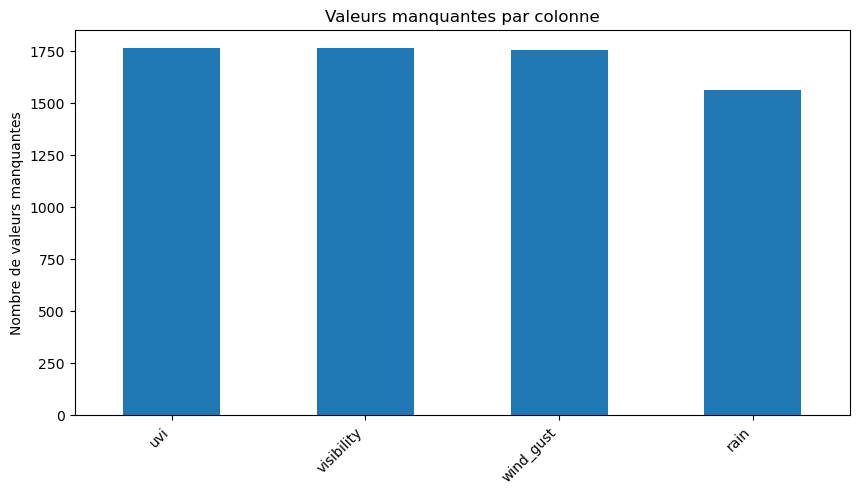

In [19]:
valeurs_manquantes_graph = valeurs_manquantes[valeurs_manquantes > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
# Prise en charge si valeurs manquetes à 0
if valeurs_manquantes_graph.empty:
    ax = plt.gca()
    ax.text(0.5, 0.5, "Aucune valeur manquante",
            ha="center", va="center", fontsize=12)
    ax.axis("off")
else:
    valeurs_manquantes_graph.plot(kind="bar")
    plt.title("Valeurs manquantes par colonne")
    plt.ylabel("Nombre de valeurs manquantes")
    plt.xticks(rotation=45, ha="right")

plt.show()

In [20]:
profile = ProfileReport(df_all, title="Analyse openwather", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:00<00:00, 1865.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Export dataframe

In [21]:
cols_to_remove = ["uvi", "visibility", "wind_gust", "weather"]
df_clean = df_all.drop(columns=cols_to_remove, errors="ignore")

In [22]:
df_clean.to_csv("../../data/openweathermap/merge_openweathermap_cleaned.csv", index=False)